# Classification with a Perceptron

A guided notebook transcribed and expanded from the Coursera
*Calculus for Machine Learning and Data Science* lecture introducing **classification**
with a perceptron (Week 3 — Optimization in Neural Networks and Newton's Method).

This notebook explains:

- how a perceptron does **binary classification** — just change the **activation function**
- the alien-language **sentiment** example (happy vs. sad)
- turning words into features and plotting the two classes
- the summation $z = w_1 x_1 + w_2 x_2 + b$ and why its raw output isn't what we want
- the **sigmoid** activation $\sigma(z) = \dfrac{1}{1+e^{-z}}$ that squashes $z$ into $(0,1)$
- a forward pass, a decision boundary, and the sigmoid curve

This notebook follows the repository `GUIDELINES.md` template and continues directly from
*Regression with a Perceptron — Gradient Descent*.

## 1. Introduction

> *"A perceptron can also represent a classification problem — in particular a binary
> classification problem. All you have to do is change the activation function."*

Regression predicts a number; **classification** predicts a **class** (here: happy or
sad). The perceptron is almost identical — we just pass the summation through a **sigmoid**
so the output lands between $0$ and $1$.

After this notebook you will be able to:

- set up a binary-classification dataset as features
- describe the classification perceptron and its decision boundary
- explain and use the sigmoid activation function

## 2. The example: alien sentiment

You meet an alien civilization whose language has only two words, **aack** and **beep**.
From four sentences you record the **mood** (happy or sad) and how often each word appears.

| sentence | # aack ($x_1$) | # beep ($x_2$) | mood |
|---|---|---|---|
| 1 | 3 | 0 | happy |
| 2 | 0 | 2 | sad |
| 3 | 1 | 3 | sad |
| 4 | 2 | 1 | happy |

The goal: predict the mood of **new** sentences from their word counts.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# features: [# aack, # beep];  label: 1 = happy, 0 = sad
X = np.array([[3, 0],
              [0, 2],
              [1, 3],
              [2, 1]], dtype=float)
y = np.array([1, 0, 0, 1])      # happy, sad, sad, happy

for (x1, x2), label in zip(X, y):
    print(f"aack={x1:.0f}, beep={x2:.0f} -> {'happy' if label==1 else 'sad'}")

aack=3, beep=0 -> happy
aack=0, beep=2 -> sad
aack=1, beep=3 -> sad
aack=2, beep=1 -> happy


### Plotting the two classes

> *"The happy points tend to be on the bottom right and the sad points on the top left."*

A straight **line** can separate the two groups — that line is what the perceptron will
represent.

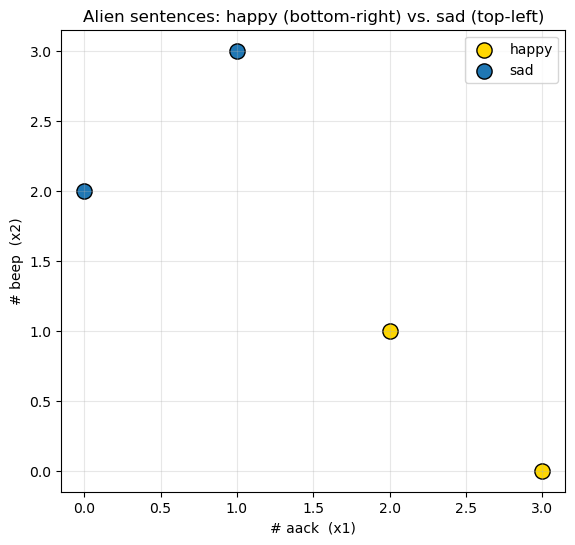

In [2]:
happy = X[y == 1]
sad   = X[y == 0]

plt.figure(figsize=(6.5, 6))
plt.scatter(happy[:, 0], happy[:, 1], s=120, color="gold", edgecolor="black", label="happy")
plt.scatter(sad[:, 0],   sad[:, 1],   s=120, color="tab:blue", edgecolor="black", label="sad")
plt.title("Alien sentences: happy (bottom-right) vs. sad (top-left)")
plt.xlabel("# aack  (x1)"); plt.ylabel("# beep  (x2)")
plt.grid(True, alpha=0.3); plt.legend()
plt.show()

## 3. The classification perceptron

Just like the regression perceptron, inputs $x_1, x_2$ are combined with weights and a
bias into a summation:

$$
z = w_1 x_1 + w_2 x_2 + b .
$$

- $w_1$ large ⇒ "aack" is strongly tied to happiness.
- $w_2$ small ⇒ "beep" barely matters.
- $w_2$ **negative** ⇒ "beep" is a *sad* word (inversely correlated with happiness).

The catch:

> *"This produces a continuous number $z$ that could be anywhere — minus a million, plus
> 7,000, zero, whatever. But now we want a number between 0 and 1: happy is 1, sad is 0."*

So we need to **squash** $z$ into $(0, 1)$.

## 4. The sigmoid activation function

The **sigmoid** maps the whole number line into $(0, 1)$:

$$
\sigma(z) = \frac{1}{1 + e^{-z}} .
$$

- very negative $z \Rightarrow \sigma(z) \approx 0$ (confidently **sad**),
- $z = 0 \Rightarrow \sigma(z) = 0.5$ (the model is **unsure**),
- very positive $z \Rightarrow \sigma(z) \approx 1$ (confidently **happy**).

> *"If you get 0.9 the model thinks the sentence is happy; if 0.01, pretty sad; if 0.5, it
> doesn't know."*

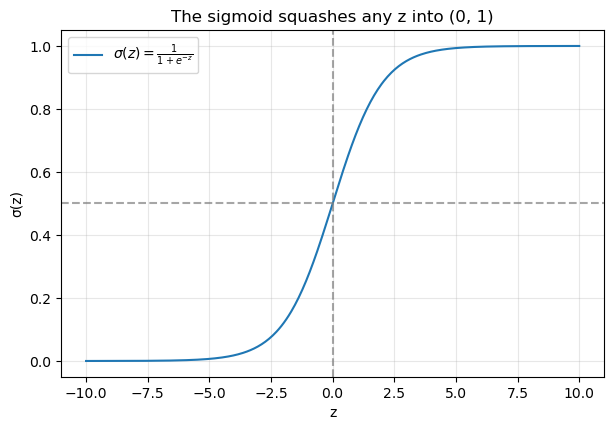

σ(-1000000.0) = 0.0000
σ(      -3) = 0.0474
σ(       0) = 0.5000
σ(       3) = 0.9526
σ(    7000) = 1.0000


/var/folders/1b/v9408tps52n06ptkrvhd1pdh0000gn/T/ipykernel_59624/1802437169.py:2: RuntimeWarning: overflow encountered in exp
  return 1 / (1 + np.exp(-z))


In [3]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

zz = np.linspace(-10, 10, 400)
plt.figure(figsize=(7, 4.5))
plt.plot(zz, sigmoid(zz), label=r"$\sigma(z)=\frac{1}{1+e^{-z}}$")
plt.axhline(0.5, color="gray", linestyle="--", alpha=0.7)
plt.axvline(0, color="gray", linestyle="--", alpha=0.7)
plt.title("The sigmoid squashes any z into (0, 1)")
plt.xlabel("z"); plt.ylabel("σ(z)")
plt.grid(True, alpha=0.3); plt.legend()
plt.show()

for z in [-1e6, -3, 0, 3, 7000]:
    print(f"σ({z:>8}) = {sigmoid(np.float64(z)):.4f}")

## 5. The full classification perceptron

The output is the summation passed through the sigmoid:

$$
\hat{y} = \sigma(z) = \sigma(w_1 x_1 + w_2 x_2 + b).
$$

With illustrative weights $w_1 = 1,\; w_2 = -1,\; b = -0.5$ (high "aack" → happy, "beep" →
sad), let's see the predictions. (Finding these weights by training is the next lectures.)

In [4]:
def classify(X, w, b):
    z = X @ w + b
    return sigmoid(z)

w = np.array([1.0, -1.0])
b = -0.5

probs = classify(X, w, b)
for (x1, x2), p, label in zip(X, probs, y):
    pred = "happy" if p >= 0.5 else "sad"
    print(f"aack={x1:.0f}, beep={x2:.0f}: σ(z)={p:.3f} -> {pred:5s}  (actual {'happy' if label else 'sad'})")

aack=3, beep=0: σ(z)=0.924 -> happy  (actual happy)
aack=0, beep=2: σ(z)=0.076 -> sad    (actual sad)
aack=1, beep=3: σ(z)=0.076 -> sad    (actual sad)
aack=2, beep=1: σ(z)=0.622 -> happy  (actual happy)


### The decision boundary

The boundary is where $z = 0$, i.e. $w_1 x_1 + w_2 x_2 + b = 0$. For our weights that is
$x_1 - x_2 - 0.5 = 0$, i.e. $x_2 = x_1 - 0.5$ — the line separating happy from sad.

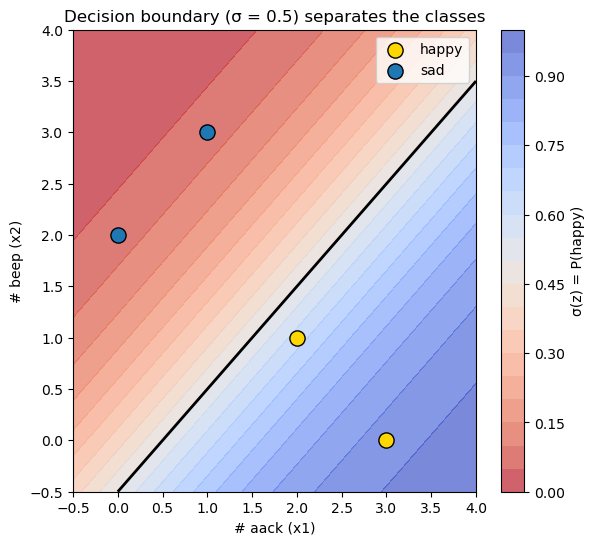

In [5]:
# probability heat-map + decision boundary
gx = np.linspace(-0.5, 4, 200)
gy = np.linspace(-0.5, 4, 200)
GX, GY = np.meshgrid(gx, gy)
GZ = sigmoid(w[0]*GX + w[1]*GY + b)

plt.figure(figsize=(6.5, 6))
cf = plt.contourf(GX, GY, GZ, levels=20, cmap="coolwarm_r", alpha=0.7)
plt.colorbar(cf, label="σ(z) = P(happy)")
plt.contour(GX, GY, GZ, levels=[0.5], colors="black", linewidths=2)
plt.scatter(happy[:, 0], happy[:, 1], s=120, color="gold", edgecolor="black", label="happy")
plt.scatter(sad[:, 0], sad[:, 1], s=120, color="tab:blue", edgecolor="black", label="sad")
plt.title("Decision boundary (σ = 0.5) separates the classes")
plt.xlabel("# aack (x1)"); plt.ylabel("# beep (x2)")
plt.legend()
plt.show()

## 6. Exercises

### Basic
1. What single change turns a regression perceptron into a classification perceptron?
2. Write the sigmoid function and its output range.

### Intermediate
3. Compute $\sigma(z)$ for $z = -2, 0, 2$.
4. For weights $w=(1,-1)$, $b=-0.5$, classify a new sentence with 4 aack and 1 beep.

### Advanced
5. What does $w_2 < 0$ mean about the word "beep" in this sentiment model?
6. Show that the decision boundary $\sigma(z) = 0.5$ is the straight line
   $w_1 x_1 + w_2 x_2 + b = 0$, and find its equation for $w=(1,-1)$, $b=-0.5$.

## 7. Solutions / Checks

In [6]:
# 3.
for z in (-2, 0, 2):
    print(f"3. σ({z:+d}) = {sigmoid(np.float64(z)):.4f}")

# 4. new sentence (4 aack, 1 beep)
new = np.array([4, 1])
p = sigmoid(new @ w + b)
print(f"4. (aack=4, beep=1): σ={p:.3f} -> {'happy' if p>=0.5 else 'sad'}")

print("5. w2 < 0 means more 'beep' lowers z, pushing σ toward 0 (sad): 'beep' is a sad word.")
print("6. σ(z)=0.5 ⟺ z=0 ⟺ w1 x1 + w2 x2 + b = 0; here x1 - x2 - 0.5 = 0, i.e. x2 = x1 - 0.5.")

3. σ(-2) = 0.1192
3. σ(+0) = 0.5000
3. σ(+2) = 0.8808
4. (aack=4, beep=1): σ=0.924 -> happy
5. w2 < 0 means more 'beep' lowers z, pushing σ toward 0 (sad): 'beep' is a sad word.
6. σ(z)=0.5 ⟺ z=0 ⟺ w1 x1 + w2 x2 + b = 0; here x1 - x2 - 0.5 = 0, i.e. x2 = x1 - 0.5.


## 8. Conclusion

- A perceptron classifies by passing the summation $z = w_1 x_1 + w_2 x_2 + b$ through an
  **activation function**.
- The **sigmoid** $\sigma(z) = \dfrac{1}{1+e^{-z}}$ squashes any real $z$ into $(0,1)$, read
  as the probability of the positive class (happy).
- The model's **decision boundary** is the line $z = 0$ ($\sigma = 0.5$), separating the
  two classes.
- Next we study the sigmoid in more detail and learn to **train** these weights — leading
  to logistic regression and neural-network classifiers.

## Appendix — Source transcript

Transcribed with OpenAI Whisper (`small.en`) from a locally downloaded video
(`~/Downloads/opt_nns_4.mp4`), the Coursera *Calculus for Machine Learning and Data
Science* (Week 3) lecture on **classification with a perceptron**. Key spoken points,
lightly cleaned (the two alien words are written here as "aack" and "beep"):

> A perceptron can do binary classification — just change the activation function. Example:
> an alien language with two words; from four sentences you record the mood (happy/sad) and
> word counts: (3,0) happy, (0,2) sad, (1,3) sad, (2,1) happy. Plotted, happy points sit
> bottom-right and sad top-left, separable by a line. The perceptron takes inputs $x_1, x_2$
> with weights $w_1, w_2$ (large if a word signals happiness, negative if it signals
> sadness) and bias $b$, forming $z = w_1 x_1 + w_2 x_2 + b$ — a continuous number that
> could be anything. But we want an output in $(0,1)$ (happy = 1, sad = 0), so we apply the
> sigmoid activation $\sigma(z) = \frac{1}{1+e^{-z}}$, which crunches the number line into
> $(0,1)$: 0.9 means happy, 0.01 means sad, 0.5 means unsure. The summation is passed
> through the sigmoid to give the output.